# Music Genre Classification — Results Visualization

Heatmaps of **TPR**, **FPR**, and **F1 Score** across feature representations and classifiers.

In [10]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

# ---------- Load results ----------
RESULTS_PATH = Path("results.json")

with RESULTS_PATH.open() as f:
    results = json.load(f)

# ---------- Extract axis labels from the data ----------
classifiers = list(results.keys())

# Collect the union of all feature names that actually appear
all_features = []
for clf_data in results.values():
    for feat in clf_data["feature_performance"]:
        if feat not in all_features:
            all_features.append(feat)

print(f"Classifiers ({len(classifiers)}): {classifiers}")
print(f"Features    ({len(all_features)}): {all_features}")

Classifiers (6): ['KNN', 'Decision Tree', 'Logistic Regression', 'MLP', 'SVM', 'XGBoost']
Features    (7): ['MFCC', 'spectrogram', 'mel_spectrogram', 'log_mel_spectrogram', 'wav2vec', 'hubert', 'mert']


In [11]:
# ---------- Build matrices ----------
metrics = ["TPR", "FPR", "F1"]
matrices = {}

for metric in metrics:
    mat = np.full((len(classifiers), len(all_features)), np.nan)
    for i, clf in enumerate(classifiers):
        for j, feat in enumerate(all_features):
            entry = results[clf]["feature_performance"].get(feat)
            if entry is not None and metric in entry:
                mat[i, j] = entry[metric]
    matrices[metric] = mat

# Quick sanity check
for m, mat in matrices.items():
    n_missing = np.isnan(mat).sum()
    print(f"{m}: shape {mat.shape}, missing cells: {n_missing}")

# ---------- Build metric matrices ----------
metrics = ["TPR", "FPR", "F1", "Accuracy"]

# Shape: (n_classifiers, n_features), filled with NaN for missing combinations
matrices = {
    m: np.full((len(classifiers), len(all_features)), np.nan)
    for m in metrics
}

for i, clf in enumerate(classifiers):
    feat_perf = results[clf]["feature_performance"]
    for j, feat in enumerate(all_features):
        if feat not in feat_perf:
            continue
        scores = feat_perf[feat]
        for m in metrics:
            if m in scores and scores[m] is not None:
                matrices[m][i, j] = scores[m]

TPR: shape (6, 7), missing cells: 0
FPR: shape (6, 7), missing cells: 0
F1: shape (6, 7), missing cells: 0


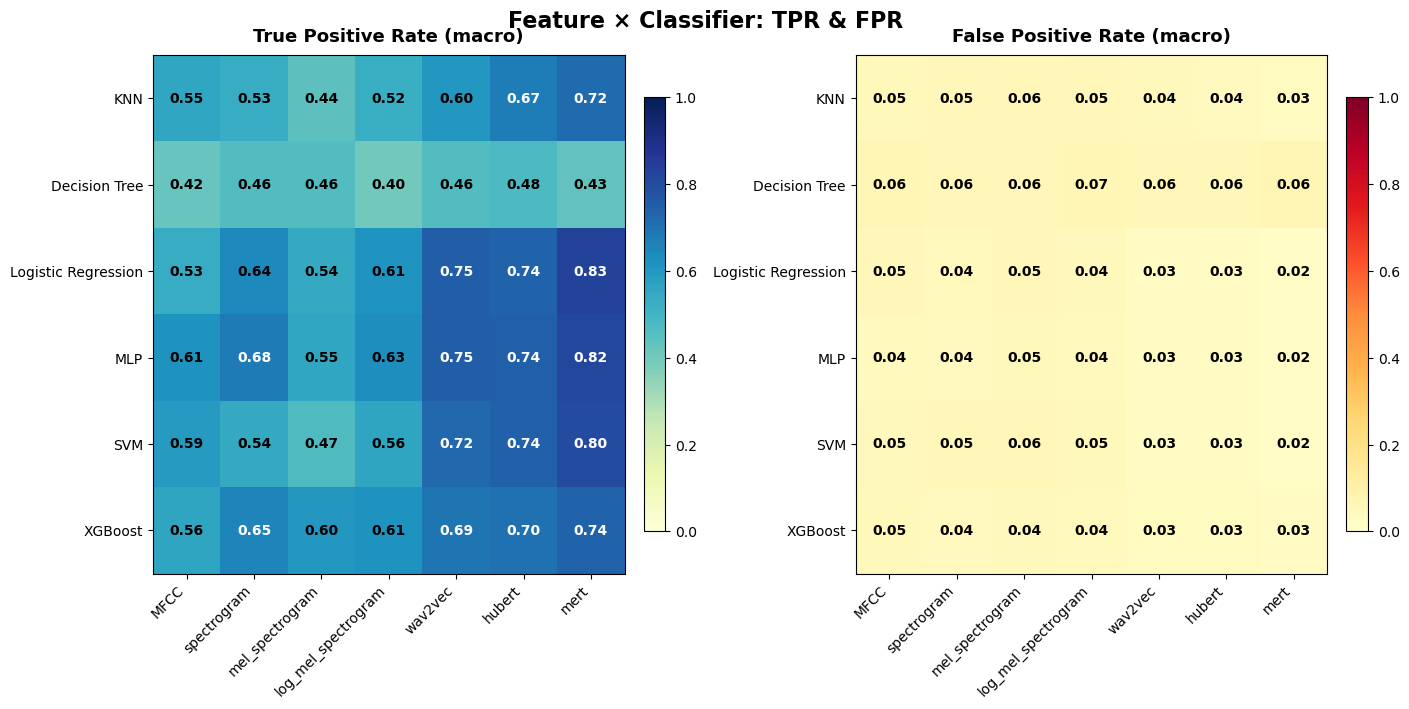

Saved → results_tpr_fpr.png


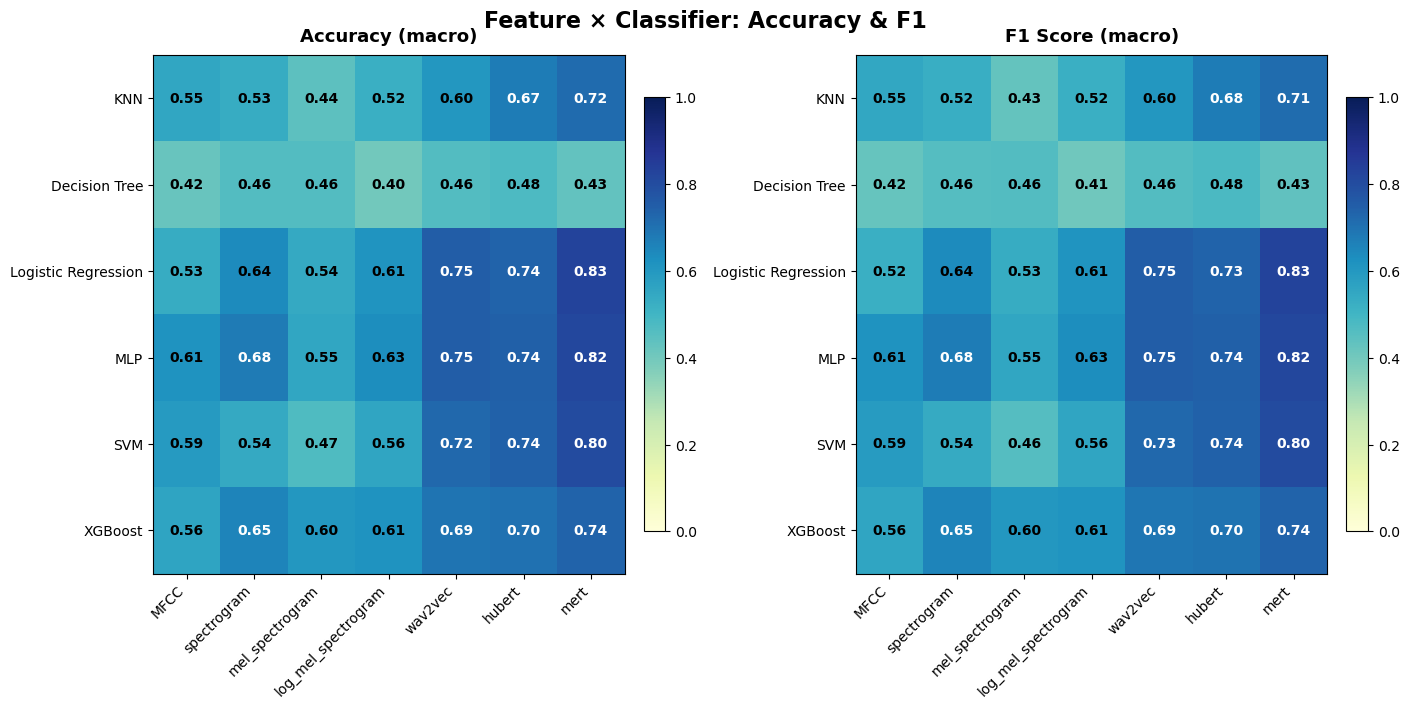

Saved → results_acc_f1.png


In [ ]:
# ---------- Plot ----------
# Colour-map choices: TPR, F1, Accuracy are "higher is better"; FPR is "lower is better"
cmap_good = "YlGnBu"   # higher = darker blue-green
cmap_bad  = "YlOrRd"   # higher = darker red  (for FPR where low is good)

metric_config = {
    "TPR":      {"cmap": cmap_good, "title": "True Positive Rate"},
    "FPR":      {"cmap": cmap_bad,  "title": "False Positive Rate"},
    "F1":       {"cmap": cmap_good, "title": "F1 Score"},
    "Accuracy": {"cmap": cmap_good, "title": "Accuracy"},
}


def _plot_heatmap(ax, data, cfg, all_features, classifiers):
    """Render a single annotated heatmap into `ax`."""
    im = ax.imshow(data, aspect="auto", cmap=cfg["cmap"], vmin=0, vmax=1)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if np.isnan(val):
                ax.text(j, i, "—", ha="center", va="center",
                        fontsize=10, color="grey")
            else:
                norm_val = mpl.colors.Normalize(vmin=0, vmax=1)(val)
                text_color = "white" if norm_val > 0.65 else "black"
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=10, fontweight="bold", color=text_color)

    ax.set_xticks(range(len(all_features)))
    ax.set_xticklabels(all_features, rotation=45, ha="right", fontsize=10)
    ax.set_yticks(range(len(classifiers)))
    ax.set_yticklabels(classifiers, fontsize=10)
    ax.set_title(cfg["title"], fontsize=13, fontweight="bold", pad=10)
    return im


def _make_figure(metric_list, suptitle, outfile, matrices, classifiers, all_features):
    n = len(metric_list)
    fig, axes = plt.subplots(
        1, n,
        figsize=(7 * n, max(5, len(classifiers) * 0.8 + 2)),
        constrained_layout=True,
    )
    if n == 1:
        axes = [axes]

    for ax, metric in zip(axes, metric_list):
        cfg = metric_config[metric]
        im = _plot_heatmap(ax, matrices[metric], cfg, all_features, classifiers)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(suptitle, fontsize=16, fontweight="bold", y=1.02)
    plt.savefig(outfile, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {outfile}")


# Figure 1: TPR and FPR
_make_figure(
    ["TPR", "FPR"],
    "Feature × Classifier: TPR & FPR",
    "results_tpr_fpr.png",
    matrices, classifiers, all_features,
)

# Figure 2: Accuracy and F1
_make_figure(
    ["Accuracy", "F1"],
    "Feature × Classifier: Accuracy & F1",
    "results_acc_f1.png",
    matrices, classifiers, all_features,
)

Feature pairs (12): ['MFCC+wav2vec', 'MFCC+hubert', 'MFCC+mert', 'spectrogram+wav2vec', 'spectrogram+hubert', 'spectrogram+mert', 'mel_spectrogram+wav2vec', 'mel_spectrogram+hubert', 'mel_spectrogram+mert', 'log_mel_spectrogram+wav2vec', 'log_mel_spectrogram+hubert', 'log_mel_spectrogram+mert']


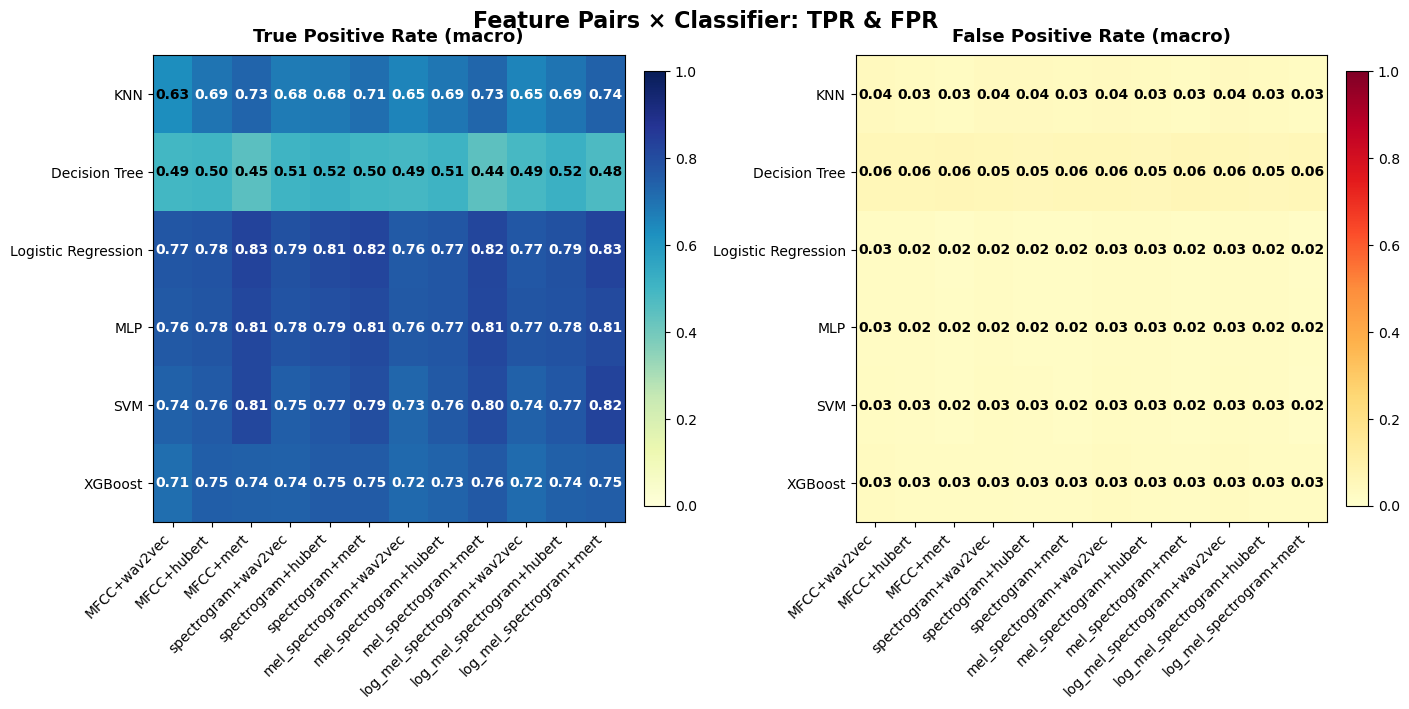

Saved → results_pairs_tpr_fpr.png


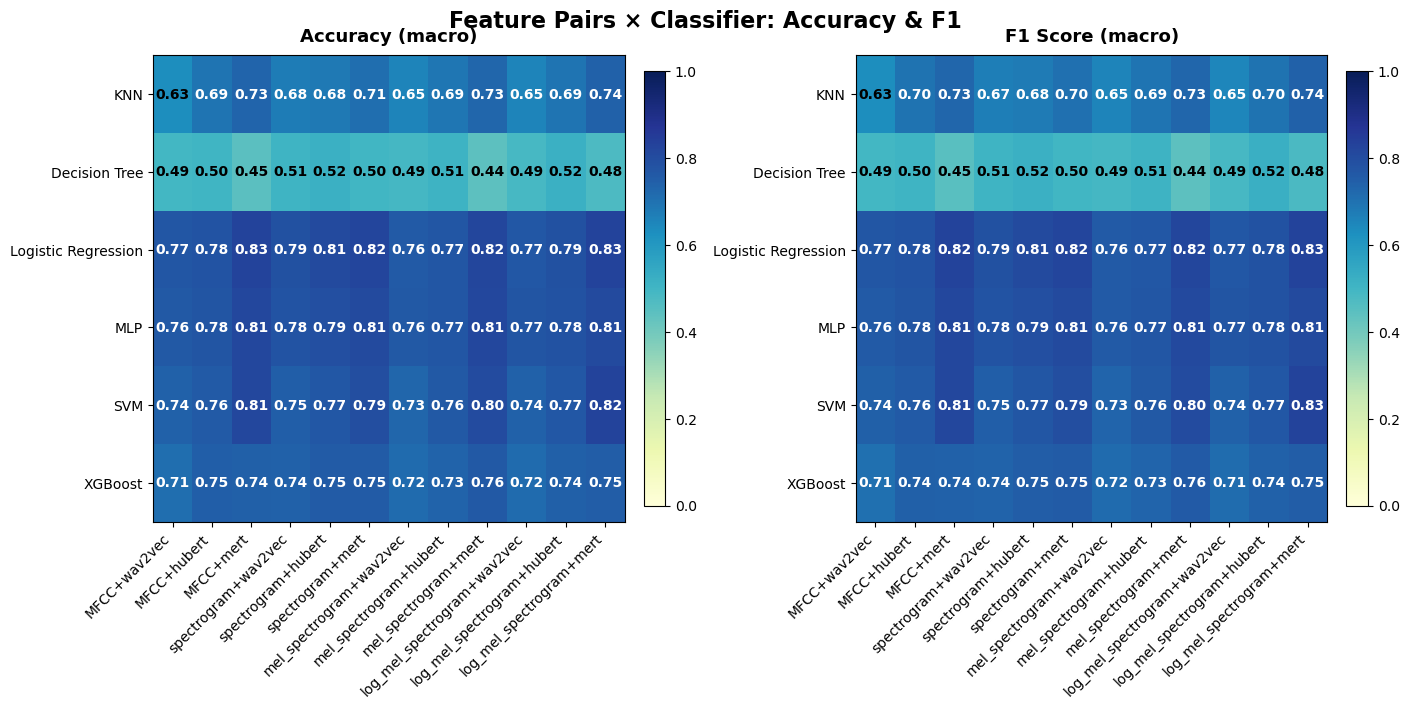

Saved → results_pairs_acc_f1.png


In [13]:
# ---------- Build matrices for paired features ----------
all_pairs = []
for clf_data in results.values():
    for pair in clf_data.get("feature_pair_performance", {}):
        if pair not in all_pairs:
            all_pairs.append(pair)

print(f"Feature pairs ({len(all_pairs)}): {all_pairs}")

pair_matrices = {
    m: np.full((len(classifiers), len(all_pairs)), np.nan)
    for m in metrics
}

for i, clf in enumerate(classifiers):
    pair_perf = results[clf].get("feature_pair_performance", {})
    for j, pair in enumerate(all_pairs):
        if pair not in pair_perf:
            continue
        scores = pair_perf[pair]
        for m in metrics:
            if m in scores and scores[m] is not None:
                pair_matrices[m][i, j] = scores[m]


# ---------- Plot paired-feature figures ----------
# Figure 3: TPR and FPR for feature pairs
_make_figure(
    ["TPR", "FPR"],
    "Feature Pairs × Classifier: TPR & FPR",
    "results_pairs_tpr_fpr.png",
    pair_matrices, classifiers, all_pairs,
)

# Figure 4: Accuracy and F1 for feature pairs
_make_figure(
    ["Accuracy", "F1"],
    "Feature Pairs × Classifier: Accuracy & F1",
    "results_pairs_acc_f1.png",
    pair_matrices, classifiers, all_pairs,
)